# Loading Data & Setup

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("phylake1337/fire-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/phylake1337/fire-dataset


In [6]:
import os, time, copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models

import matplotlib.pyplot as plt
from collections import Counter
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

import kagglehub
import warnings
warnings.filterwarnings('ignore')

# Télécharger dataset
path = kagglehub.dataset_download("phylake1337/fire-dataset")

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_gpus = torch.cuda.device_count() if torch.cuda.is_available() else 1

# Config
SEED = 42
NUM_EPOCHS = 10
BATCH_SIZE = 64 * max(num_gpus, 1)

torch.manual_seed(SEED)
np.random.seed(SEED)

# Dataset path
DATA_DIR = path

print("Dataset path:", DATA_DIR)
print(f'Device: {device} | GPUs: {num_gpus} | Batch: {BATCH_SIZE}')

Dataset path: /kaggle/input/datasets/phylake1337/fire-dataset
Device: cuda | GPUs: 2 | Batch: 128


# Piste 0 : Baseline Data Loading 

Try to understand all the transformation below ...

In [12]:
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(20),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225]
        )
    ]),

    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225]
        )
    ]),
}

# APRÈS (correct)
TRAIN_PATH = os.path.join(DATA_DIR, "fire_dataset")
# → ImageFolder voit : ['fire_images', 'non_fire_images']  ← 2 vraies classes

# Deux datasets séparés
train_full = datasets.ImageFolder(
    TRAIN_PATH,
    transform=data_transforms['train']
)

val_full = datasets.ImageFolder(
    TRAIN_PATH,
    transform=data_transforms['val']
)

# Classes
class_names = train_full.classes

# Split train / validation
torch.manual_seed(SEED)

indices = torch.randperm(len(train_full)).tolist()

split = int(0.8 * len(indices))

train_idx = indices[:split]
val_idx   = indices[split:]

# Subsets
train_dataset = Subset(train_full, train_idx)
val_dataset   = Subset(val_full, val_idx)

# DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

# Infos
print(f'Classes: {class_names}')
print(f'Train: {len(train_dataset)}')
print(f'Val: {len(val_dataset)}')

print(
    f'Distribution: '
    f'{Counter([train_full.targets[i] for i in train_idx])}'
)

Classes: ['fire_images', 'non_fire_images']
Train: 799
Val: 200
Distribution: Counter({0: 602, 1: 197})


## Exploring Data

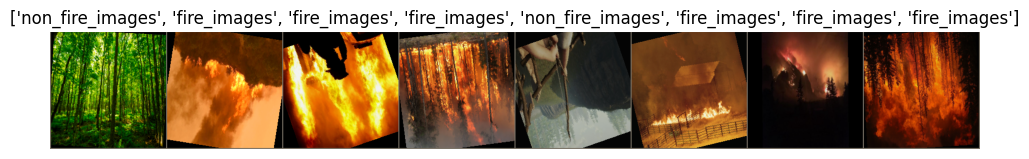

In [14]:
import torchvision

# Fonction affichage
def imshow(inp, title=None):
    # Tensor -> numpy
    inp = inp.cpu().numpy().transpose((1, 2, 0))
    # Annuler Normalize
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    # Affichage
    plt.figure(figsize=(12, 6))
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.axis('off')
    plt.show()

# Récupération d'un batch
inputs, classes = next(iter(train_loader))

# Grille des 8 premières images
out = torchvision.utils.make_grid(inputs[:8])

# Affichage
imshow(
    out,
    title=[class_names[x] for x in classes[:8]]
)  

# Piste 0 : Baseline Model

In [16]:
# Construction du modèle
def build_baseline_model():
    # ResNet50 pré-entraîné
    model = models.resnet50(
        weights=models.ResNet50_Weights.DEFAULT
    )

    # Geler toutes les couches (feature extraction)
    for param in model.parameters():
        param.requires_grad = False

    # Nombre d'entrées de la dernière couche
    num_ftrs = model.fc.in_features

    # Nouvelle couche finale (seule partie entraînable)
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(num_ftrs, len(class_names))  # len(class_names) doit valoir 2 maintenant
    )

    # Multi-GPU
    if num_gpus > 1:
        model = nn.DataParallel(model)

    return model.to(device)

# Model
model = build_baseline_model()

# Loss
criterion = nn.CrossEntropyLoss()

# Optimizer — seulement les paramètres entraînables (fc)
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

# Scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS
)

# Nombre de paramètres
total   = sum(p.numel() for p in model.parameters())
trained = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Paramètres totaux       : {total:,}')
print(f'Paramètres entraînables : {trained:,}')   # ~4 097 (fc seulement)
print(f'Classes détectées       : {class_names}')  # doit afficher 2 classes

Paramètres totaux       : 23,512,130
Paramètres entraînables : 4,098
Classes détectées       : ['fire_images', 'non_fire_images']


# Train Function & Helper

In [18]:
# Fonction d'entraînement
def train_model(
    model,
    criterion,
    optimizer,
    scheduler=None,
    num_epochs=NUM_EPOCHS,
    train_loader=train_loader,
    val_loader=val_loader,
    label='run'
):
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': []
    }

    best_val_acc = 0.0
    best_weights = copy.deepcopy(model.state_dict())
    since = time.time()

    for epoch in range(num_epochs):

        print(f'Epoch {epoch+1}/{num_epochs} [{label}]')

        for phase in ['train', 'val']:

            if phase == 'train':
                model.train()
            else:
                model.eval()

            loader = train_loader if phase == 'train' else val_loader

            running_loss     = 0.0
            running_corrects = 0

            for inputs, labels in loader:

                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):

                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss     += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            # Métriques epoch
            epoch_loss = running_loss / len(loader.dataset)
            epoch_acc  = running_corrects.double() / len(loader.dataset)

            print(
                f'  {phase:5s} '
                f'Loss: {epoch_loss:.4f}  '
                f'Acc: {epoch_acc:.4f}'
            )

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())

            # Sauvegarde meilleur modèle
            if phase == 'val' and epoch_acc > best_val_acc:
                best_val_acc = epoch_acc
                best_weights = copy.deepcopy(model.state_dict())

        # Scheduler step après les deux phases
        if scheduler:
            scheduler.step()

        print()

    # Temps total
    time_elapsed = time.time() - since
    print(
        f'✅ Entraînement terminé en '
        f'{time_elapsed // 60:.0f}m '
        f'{time_elapsed % 60:.0f}s'
    )
    print(f'🏆 Meilleure Val Acc: {best_val_acc:.4f}')

    # Charger meilleur modèle
    model.load_state_dict(best_weights)

    return model, history


# Fonction affichage courbes
def plot_history(history, title=''):

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    epochs = range(1, len(history['train_loss']) + 1)

    for ax, metric in zip(axes, ['loss', 'acc']):

        ax.plot(epochs, history[f'train_{metric}'], 'b-o', label='Train')
        ax.plot(epochs, history[f'val_{metric}'],   'r-o', label='Validation')

        ax.set_title(metric.capitalize())
        ax.set_xlabel('Epoch')
        ax.set_ylabel(metric.capitalize())  # ← ajout axe Y
        ax.legend()
        ax.grid(True, alpha=0.3)            # ← ajout grille lisibilité

    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    best_acc = max(history['val_acc'])
    print(f'📊 Best Val Acc: {best_acc:.4f} ({best_acc * 100:.2f}%)')


print("✅ OK")

✅ OK


# Launch Baseline 

In [19]:
model, history_baseline = train_model(
    model,
    criterion,
    optimizer,
    scheduler=scheduler,
    label='Baseline'
)

Epoch 1/10 [Baseline]
  train Loss: 0.6472  Acc: 0.6809
  val   Loss: 0.5910  Acc: 0.7950

Epoch 2/10 [Baseline]
  train Loss: 0.5960  Acc: 0.7660
  val   Loss: 0.5448  Acc: 0.7850

Epoch 3/10 [Baseline]
  train Loss: 0.5613  Acc: 0.7697
  val   Loss: 0.5159  Acc: 0.7900

Epoch 4/10 [Baseline]
  train Loss: 0.5349  Acc: 0.7635
  val   Loss: 0.4956  Acc: 0.7800

Epoch 5/10 [Baseline]
  train Loss: 0.5127  Acc: 0.7610
  val   Loss: 0.4804  Acc: 0.7750

Epoch 6/10 [Baseline]
  train Loss: 0.5001  Acc: 0.7635
  val   Loss: 0.4710  Acc: 0.7750

Epoch 7/10 [Baseline]
  train Loss: 0.4921  Acc: 0.7559
  val   Loss: 0.4663  Acc: 0.7900

Epoch 8/10 [Baseline]
  train Loss: 0.4860  Acc: 0.7622
  val   Loss: 0.4640  Acc: 0.7750

Epoch 9/10 [Baseline]
  train Loss: 0.4786  Acc: 0.7635
  val   Loss: 0.4588  Acc: 0.7800

Epoch 10/10 [Baseline]
  train Loss: 0.4833  Acc: 0.7572
  val   Loss: 0.4592  Acc: 0.7750

✅ Entraînement terminé en 2m 42s
🏆 Meilleure Val Acc: 0.7950


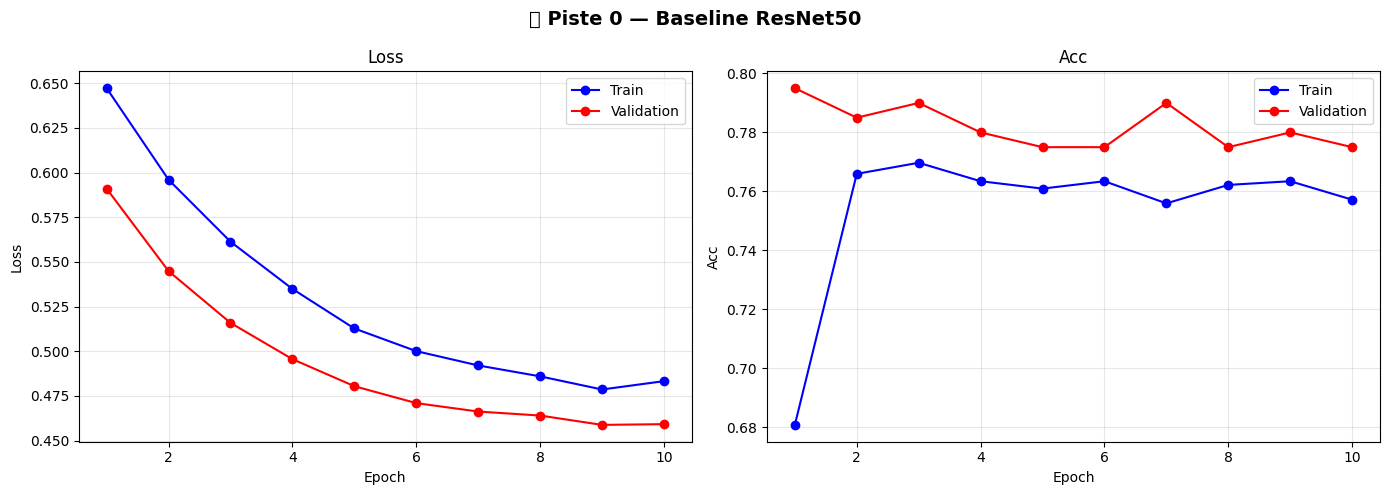

📊 Best Val Acc: 0.7950 (79.50%)


In [20]:
plot_history(history_baseline, '🟢 Piste 0 — Baseline ResNet50')

# Piste 1 : Advanced Augmentation

In [6]:
# =========================
# Piste 1 : Augmentation
# =========================

data_transforms_p1 = {

    'train': transforms.Compose([

        transforms.Resize((224, 224)),

        transforms.RandomHorizontalFlip(p=0.5),

        transforms.RandomVerticalFlip(p=0.5),

        transforms.RandomRotation(15),

        transforms.ColorJitter(
            brightness=0.2,
            contrast=0.2,
            saturation=0.1,
            hue=0.05
        ),

        transforms.RandomGrayscale(p=0.1),

        transforms.GaussianBlur(
            kernel_size=3,
            sigma=(0.1, 2.0)
        ),

        transforms.ToTensor(),

        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225]
        )
    ]),

    'val': transforms.Compose([

        transforms.Resize((224, 224)),

        transforms.ToTensor(),

        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225]
        )
    ]),
}

# Dataset path
TRAIN_PATH = DATA_DIR

# Datasets
train_full_p1 = datasets.ImageFolder(
    TRAIN_PATH,
    transform=data_transforms_p1['train']
)

val_full_p1 = datasets.ImageFolder(
    TRAIN_PATH,
    transform=data_transforms_p1['val']
)

# DataLoaders
train_loader_p1 = DataLoader(
    Subset(train_full_p1, train_idx),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader_p1 = DataLoader(
    Subset(val_full_p1, val_idx),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

# Model
model_p1 = build_baseline_model()

# Optimizer
optimizer_p1 = optim.Adam(
    filter(lambda p: p.requires_grad, model_p1.parameters()),
    lr=1e-4
)

# Scheduler
scheduler_p1 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_p1,
    T_max=NUM_EPOCHS
)

# Training
model_p1, history_p1 = train_model(
    model_p1,
    criterion,
    optimizer_p1,
    scheduler=scheduler_p1,
    train_loader=train_loader_p1,
    val_loader=val_loader_p1,
    label='P1-Augmentation'
)

# Courbes
plot_history(
    history_p1,
    '🔵 Piste 1 — Augmentation Avancée'
)

NameError: name 'transforms' is not defined